In [1]:
from medmnist import BreastMNIST
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import cv2
import random
import os
import seaborn as sns
import config
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
np.random.seed(config.RANDOM_SEED)
random.seed(config.RANDOM_SEED)

In [3]:
def horizontal_flip(image):
    return cv2.flip(image, 1)

def rotate(image, angle):
    h, w = image.shape[:2]
    center = (w // 2, h // 2)
    matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    return cv2.warpAffine(image, matrix, (w, h), borderMode=cv2.BORDER_REFLECT)

def translate(image, tx, ty):
    h, w = image.shape[:2]
    matrix = np.float32([[1, 0, tx], [0, 1, ty]])
    return cv2.warpAffine(image, matrix, (w, h), borderMode=cv2.BORDER_REFLECT)

def adjust_brightness(image, factor):
    image = image.astype(np.float32)
    image = image * factor
    return np.clip(image, 0, 255).astype(np.uint8)

def adjust_contrast(image, factor):
    mean = np.mean(image, axis=(0, 1), keepdims=True)
    image = image.astype(np.float32)
    image = (image - mean) * factor + mean
    return np.clip(image, 0, 255).astype(np.uint8)

In [4]:
def augment_image(image):
    image = image.copy()
    transforms = []

    # --- Geometric transforms ---
    if np.random.rand() < 0.5:
        transforms.append(lambda x: horizontal_flip(x))

    if np.random.rand() < 0.3:
        transforms.append(lambda x: rotate(x, np.random.uniform(-10, 10)))

    if np.random.rand() < 0.3:
        transforms.append(
            lambda x: translate(
                x,
                np.random.randint(-2, 3),
                np.random.randint(-2, 3),
            )
        )

    # --- Photometric transforms (BEFORE Canny) ---
    if np.random.rand() < 0.3:
        transforms.append(
            lambda x: adjust_brightness(x, np.random.uniform(0.95, 1.05))
        )

    if np.random.rand() < 0.3:
        transforms.append(
            lambda x: adjust_contrast(x, np.random.uniform(0.95, 1.05))
        )

    # --- Apply at most two transformations ---
    np.random.shuffle(transforms)
    for t in transforms[:2]:
        image = t(image)

    return image


In [5]:
# Download dataset splits
train_dataset = BreastMNIST(split='train', download=True)
val_dataset   = BreastMNIST(split='val',   download=True)
test_dataset  = BreastMNIST(split='test',  download=True)

# Extract images and labels
X_train = train_dataset.imgs.astype(np.uint8)
Y_train = train_dataset.labels.flatten()

X_val   = val_dataset.imgs.astype(np.uint8)
Y_val   = val_dataset.labels.flatten()

X_test  = test_dataset.imgs.astype(np.uint8)
Y_test  = test_dataset.labels.flatten()

# Sanity checks
print("Image shapes:", X_train.shape, X_val.shape, X_test.shape)
print("Label shapes:", Y_train.shape, Y_val.shape, Y_test.shape)

# Class labels
labels = config.labels

print("Class mapping:", labels)

Image shapes: (546, 28, 28) (78, 28, 28) (156, 28, 28)
Label shapes: (546,) (78,) (156,)
Class mapping: {0: 'Malignant', 1: 'Benign'}


Displaying 5 images from Class 0



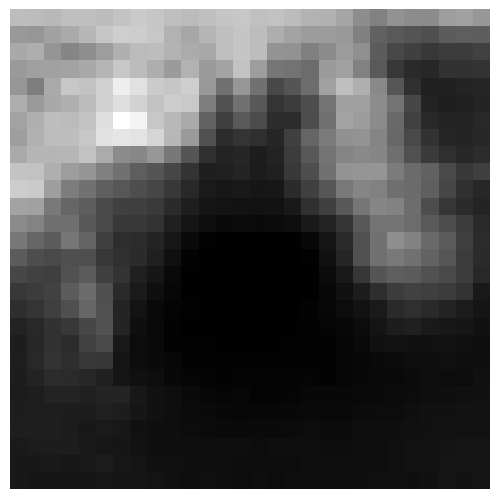

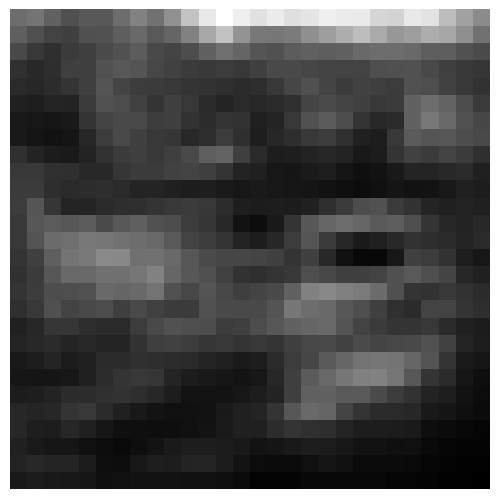

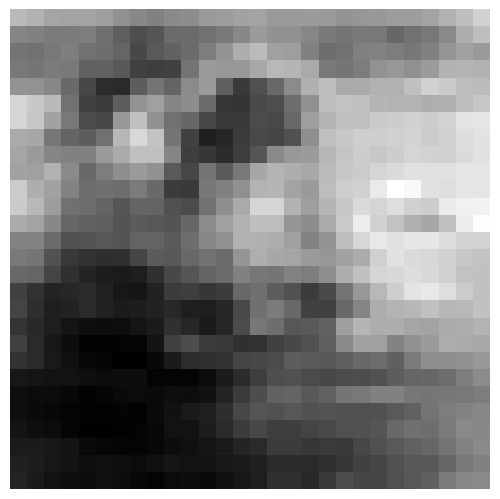

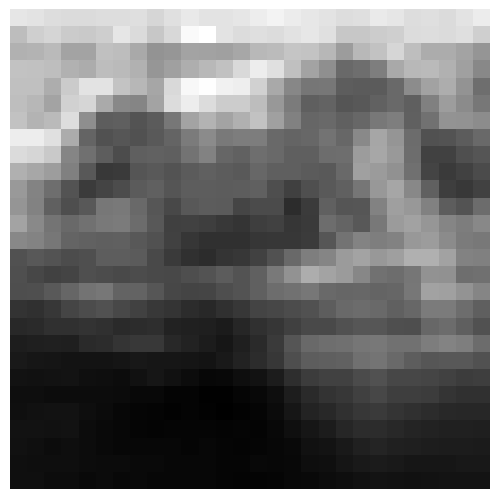

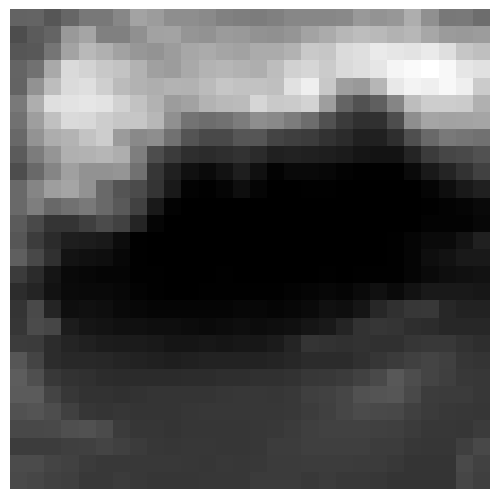

Displaying 5 images from Class 1



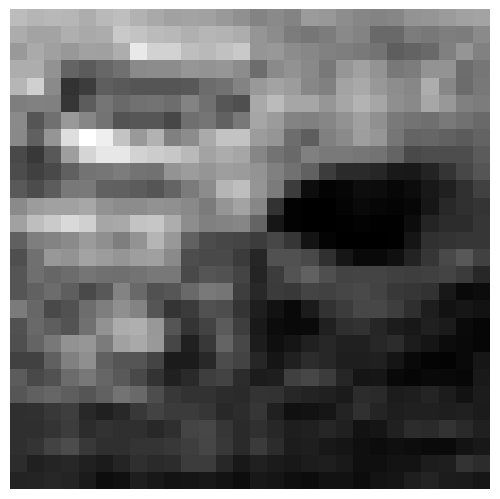

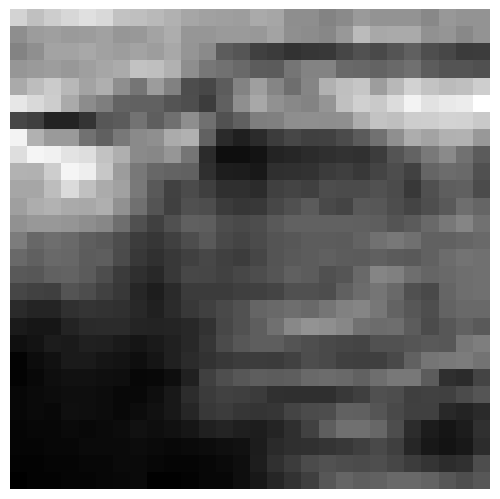

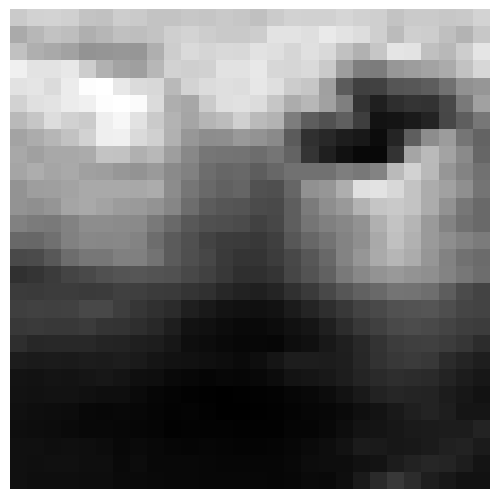

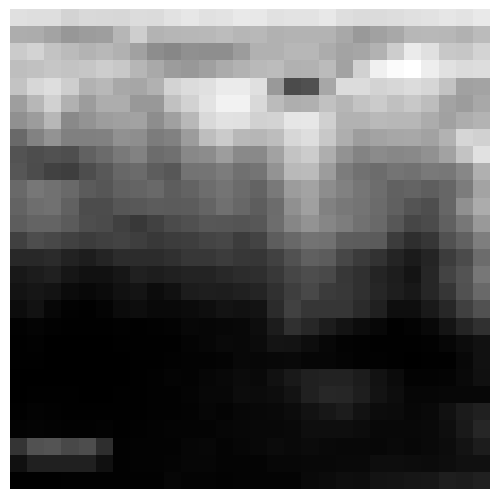

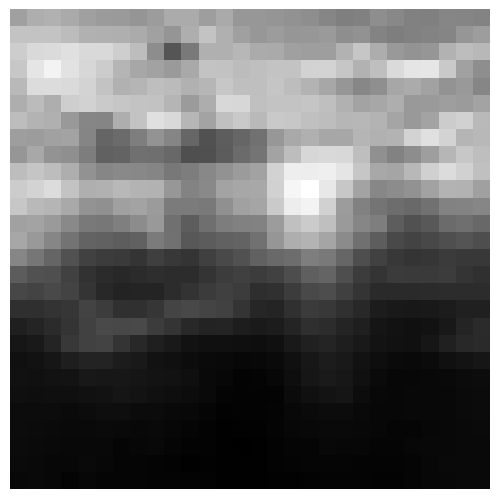

In [6]:
class0_indices = np.where(Y_train == 0)[0]
class1_indices = np.where(Y_train == 1)[0]

selected_class0 = np.random.choice(class0_indices, 5, replace=False)
selected_class1 = np.random.choice(class1_indices, 5, replace=False)

def show_image(img):
    fig = plt.figure(frameon=False)
    ax = plt.Axes(fig, [0., 0., 1., 1.])
    ax.set_axis_off()
    fig.add_axes(ax)
    ax.imshow(img.squeeze(), cmap="gray")
    plt.show()

print("Displaying 5 images from Class 0\n")
for idx in selected_class0:
    show_image(X_train[idx])

print("Displaying 5 images from Class 1\n")
for idx in selected_class1:
    show_image(X_train[idx])

In [7]:
def show_class_distribution(Y, split_name):
    unique, counts = np.unique(Y, return_counts=True)
    print(f"\nClass distribution in {split_name}:")
    for u, c in zip(unique, counts):
        print(f"  {u}: {labels[u]} — {c} samples")
    total = counts.sum()
    print(f"  Total samples: {total}")
    return pd.DataFrame({
        'class_id': unique,
        'label': [labels[u] for u in unique],
        'count': counts
    })

In [8]:
def plot_class_histograms_horizontal(train_df, val_df, test_df, save_path=None, y_limit=None):
    sns.set_style("whitegrid")
    fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
    splits = [
        ("Train", train_df),
        ("Validation", val_df),
        ("Test", test_df),
    ]
    for ax, (name, df) in zip(axes, splits):
        sns.barplot(
            data=df,
            x="label",
            y="count",
            ax=ax,
            color="#79d7fc"
        )
        ax.set_title(name)
        ax.set_xlabel("Class")
        ax.set_ylabel("Number of samples")
        ax.set_xticklabels(ax.get_xticklabels(), ha="center")
        for p in ax.patches:
            height = p.get_height()
            ax.annotate(
                f"{int(height)}",
                (p.get_x() + p.get_width() / 2., height),
                ha='center',
                va='bottom',
                fontsize=11
            )
        if y_limit is not None:
            ax.set_ylim(top=y_limit)
    fig.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, format="svg", bbox_inches="tight")
        print(f"Saved to: {save_path}")
    plt.show()




Class distribution in Train:
  0: Malignant — 147 samples
  1: Benign — 399 samples
  Total samples: 546

Class distribution in Validation:
  0: Malignant — 21 samples
  1: Benign — 57 samples
  Total samples: 78

Class distribution in Test:
  0: Malignant — 42 samples
  1: Benign — 114 samples
  Total samples: 156


/tmp/ipykernel_688853/2948545633.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha="center")
/tmp/ipykernel_688853/2948545633.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha="center")
/tmp/ipykernel_688853/2948545633.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha="center")


Saved to: breast_mnist_class_distribution.svg


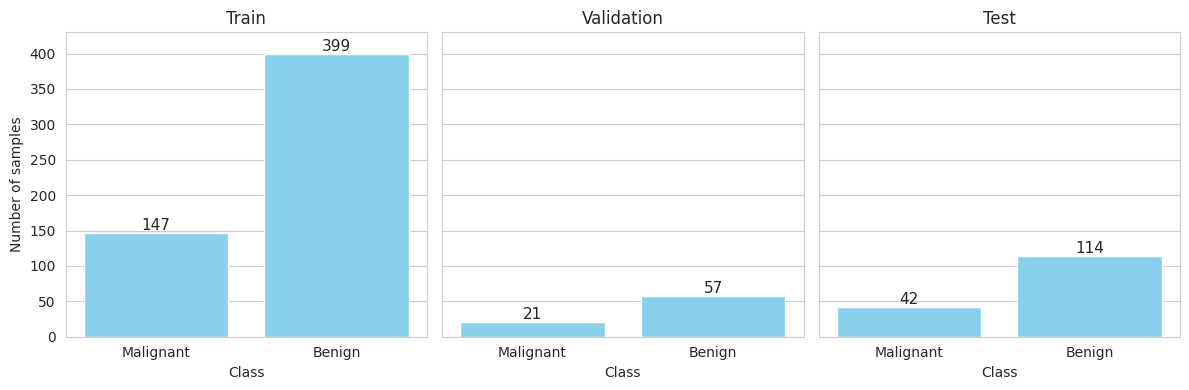

In [13]:
train_counts = show_class_distribution(Y_train, "Train")
val_counts   = show_class_distribution(Y_val, "Validation")
test_counts  = show_class_distribution(Y_test, "Test")

plot_class_histograms_horizontal(train_counts, val_counts, test_counts, save_path="breast_mnist_class_distribution.svg", y_limit=430)

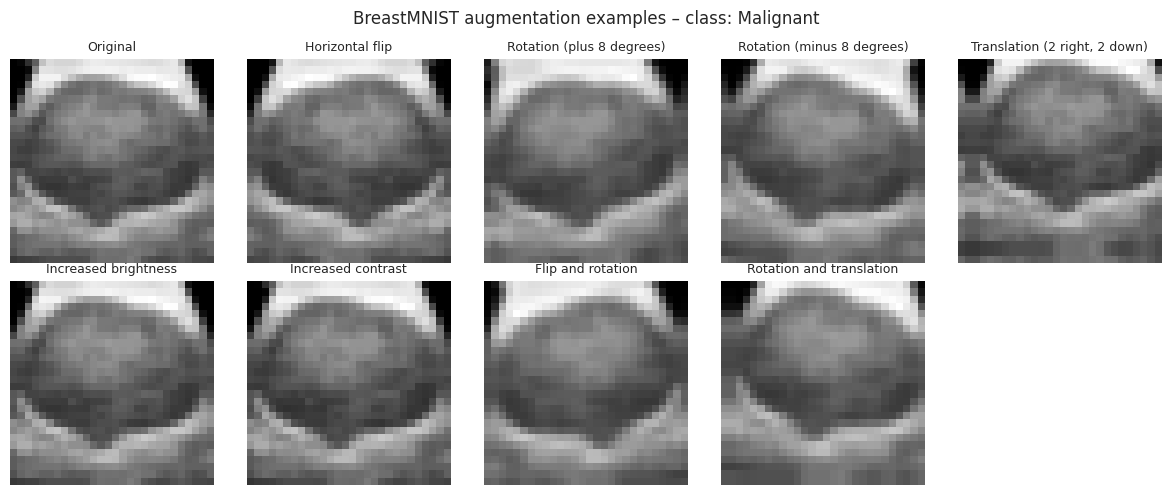

In [10]:
idx = 4
image = X_train[idx]
label = Y_train[idx]

# Generate examples that reflect possible combinations
augmented_images = [
    ("Original", image),
    ("Horizontal flip", horizontal_flip(image)),
    ("Rotation (plus 8 degrees)", rotate(image, 8)),
    ("Rotation (minus 8 degrees)", rotate(image, -8)),
    ("Translation (2 right, 2 down)", translate(image, 2, -2)),
    ("Increased brightness", adjust_brightness(image, 1.05)),
    ("Increased contrast", adjust_contrast(image, 1.05)),
    ("Flip and rotation", rotate(horizontal_flip(image), 6)),
    ("Rotation and translation", translate(rotate(image, -6), 1, -1)),
]

# Plot in a grid (2 rows)
plt.figure(figsize=(12, 5))

for i, (title, img) in enumerate(augmented_images):
    plt.subplot(2, 5, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(title, fontsize=9)
    plt.axis("off")

plt.suptitle(
    f"BreastMNIST augmentation examples – class: {labels[label]}",
    fontsize=12
)
plt.tight_layout()
plt.show()


In [11]:
# 1. Identify minority class
minority_class = 0  # Malignant

# 2. Separate training data
X_min = X_train[Y_train == minority_class]
X_maj = X_train[Y_train != minority_class]

# 3. Augment minority class
X_min_aug = []
for img in X_min:
    for _ in range(2):  # 3–5x augmentation
        X_min_aug.append(augment_image(img))

# 4. Recombine training set
X_train_balanced = np.concatenate([X_maj, X_min, X_min_aug])
y_train_balanced = np.concatenate([
    Y_train[Y_train != minority_class],
    np.full(len(X_min), minority_class),
    np.full(len(X_min_aug), minority_class)
])



Class distribution in Train:
  0: Malignant — 441 samples
  1: Benign — 399 samples
  Total samples: 840

Class distribution in Validation:
  0: Malignant — 21 samples
  1: Benign — 57 samples
  Total samples: 78

Class distribution in Test:
  0: Malignant — 42 samples
  1: Benign — 114 samples
  Total samples: 156


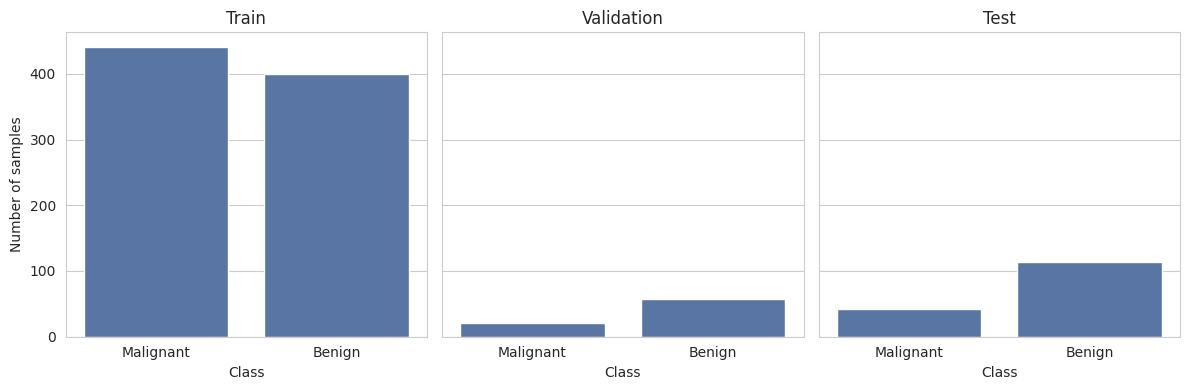

In [12]:
train_counts = show_class_distribution(y_train_balanced, "Train")
val_counts   = show_class_distribution(Y_val, "Validation")
test_counts  = show_class_distribution(Y_test, "Test")

plot_class_histograms_horizontal(train_counts, val_counts, test_counts)

In [13]:
X_train = X_train_balanced
X_val   = X_val
X_test  = X_test
Y_test  = Y_test
Y_train  = y_train_balanced
Y_val = Y_val

In [14]:

os.makedirs(config.DATA_DIR, exist_ok=True)

In [15]:
np.save(os.path.join(config.DATA_DIR, "X_train_balanced.npy"), X_train)
np.save(os.path.join(config.DATA_DIR, "Y_train_balanced.npy"), Y_train)

np.save(os.path.join(config.DATA_DIR, "X_test.npy"), X_test)
np.save(os.path.join(config.DATA_DIR, "Y_test.npy"), Y_test)

np.save(os.path.join(config.DATA_DIR, "X_val.npy"), X_val)
np.save(os.path.join(config.DATA_DIR, "Y_val.npy"), Y_val)


In [16]:
X_train_balanced = np.load(os.path.join(config.DATA_DIR, "X_train_balanced.npy"))
y_train_balanced = np.load(os.path.join(config.DATA_DIR, "Y_train_balanced.npy"))

X_test = np.load(os.path.join(config.DATA_DIR, "X_test.npy"))
y_test = np.load(os.path.join(config.DATA_DIR, "Y_test.npy"))

X_val = np.load(os.path.join(config.DATA_DIR, "X_val.npy"))
y_val = np.load(os.path.join(config.DATA_DIR, "Y_val.npy"))


Class distribution in Train:
  0: Malignant — 441 samples
  1: Benign — 399 samples
  Total samples: 840

Class distribution in Validation:
  0: Malignant — 21 samples
  1: Benign — 57 samples
  Total samples: 78

Class distribution in Test:
  0: Malignant — 42 samples
  1: Benign — 114 samples
  Total samples: 156


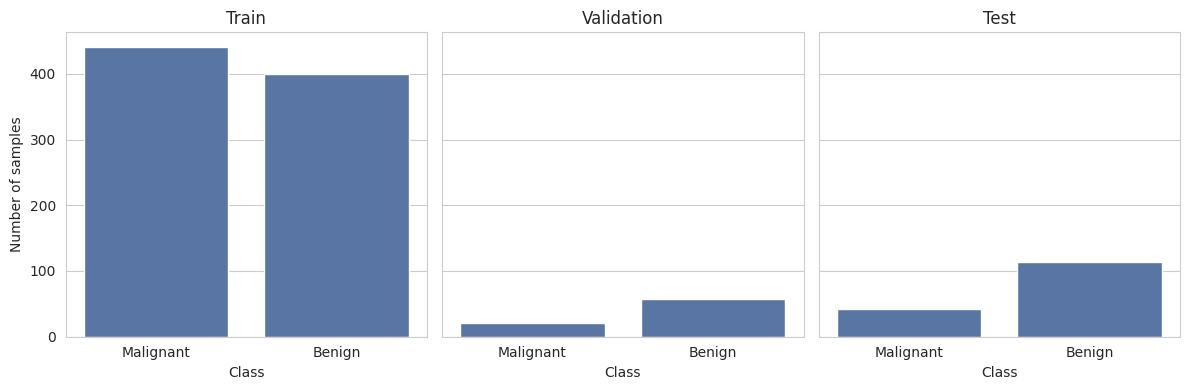

In [17]:
train_counts = show_class_distribution(y_train_balanced, "Train")
val_counts   = show_class_distribution(y_val, "Validation")
test_counts  = show_class_distribution(y_test, "Test")

plot_class_histograms_horizontal(train_counts, val_counts, test_counts)